In [50]:
import pandas as pd
import numpy as np
import matplotlib as mlt
import scipy.stats as ss

In [51]:
PATH = 'EVALMASTER.xlsx'

In [52]:
df = pd.read_excel(PATH)
print(df.head(5))
df.describe()

   Grupo de control  Nivel glucosa basal  Nivel glucosa 60 min
0                 1                   90                   159
1                 1                   82                   151
2                 1                   80                   148
3                 1                   75                   138
4                 1                   74                   141


,Grupo de control,Nivel glucosa basal,Nivel glucosa 60 min
count,65.000000,65.000000,65.000000
mean,1.461538,86.861538,160.292308
std,0.502398,8.462928,14.231043
min,1.000000,65.000000,131.000000
25%,1.000000,80.000000,149.000000
50%,1.000000,88.000000,159.000000
75%,2.000000,93.000000,172.000000
max,2.000000,104.000000,197.000000


# EJERCICO 1
## A. Medidas de centralización

In [53]:
# Agrupar por 'Grupo de control' y calcular medidas de centralización y dispersión para 'Nivel glucosa basal'
grouped = df.groupby('Grupo de control')['Nivel glucosa basal']
stats = grouped.agg(['count','min','max','mean','median'])
# Calcular la(s) moda(s) por grupo (puede haber más de una)
modes = grouped.apply(lambda s: s.mode().tolist())
stats['mode'] = modes
# Dispersion
stats_dispersion = grouped.agg(['std','var'])
iqr = grouped.quantile(0.75) - grouped.quantile(0.25)
stats['std'], stats['var'] = stats_dispersion['std'], stats_dispersion['var']
stats['IQR'] = iqr

sk_by_group = df.groupby('Grupo de control')['Nivel glucosa basal'] \
                .apply(lambda x: ss.skew(x.dropna(), bias=False))

print(stats)

                  count  min  max       mean  median              mode  \
Grupo de control                                                         
1                    35   65  103  84.685714    82.0  [75, 79, 82, 90]   
2                    30   77  104  89.400000    90.0              [88]   

                       std        var   IQR  
Grupo de control                             
1                 8.844312  78.221849  12.0  
2                 7.346592  53.972414   9.5  


A) La media es una claramente respresentativa, en grupo 2 casi perfecta. Las medias y medianas son muy parecidas y el coeficeinte de variacion es ~0, aunque el grupo 1 tiene una variacion ligeramente positiva.

In [54]:
#Cálculo de simetría y curtosis para el grupo 2 (adultos)
col_group = 'Grupo de control'
col_basal = 'Nivel glucosa basal'
x = df.loc[df[col_group] == 2, col_basal].dropna()
skew = ss.skew(x, bias=False)
kurt_excess = ss.kurtosis(x, fisher=True, bias=False)
pearson_kurt = ss.kurtosis(x, fisher=False, bias=False)
print('--- Grupo 2 (adultos) ---')
print('n =', len(x))
print(f'Skewness: {skew:.6f}')
print(f'Excess kurtosis (Fisher): {kurt_excess:.6f}')
print(f'Pearson kurtosis: {pearson_kurt:.6f}')
print(x.describe())

--- Grupo 2 (adultos) ---
n = 30
Skewness: -0.007469
Excess kurtosis (Fisher): -0.612661
Pearson kurtosis: 2.387339
count     30.000000
mean      89.400000
std        7.346592
min       77.000000
25%       84.500000
50%       90.000000
75%       94.000000
max      104.000000
Name: Nivel glucosa basal, dtype: float64


** Resultados para Nivel glucosa basal en adultos (grupo 2)**

- **Simetría (skewness):** -0.00747 (prácticamente 0 → distribución simétrica)
- **Curtosis (exceso):** -0.61266 (platykurtic — colas/peak más planas que la normal)
- **Curtosis (Pearson):** 2.38734
- **Media:** 89.40, **Desviación estándar:** 7.35

# C. Cuartiles

In [55]:
# Cálculo de cuartiles y box-plot para el grupo 1 (jóvenes)
import matplotlib.pyplot as plt
col_group = 'Grupo de control'
col_basal = 'Nivel glucosa basal'
col_60 = 'Nivel glucosa 60 min'
g1 = df.loc[df[col_group] == 1]
# Cuartiles
q_basal = g1[col_basal].quantile([0.25, 0.5, 0.75])
q_60 = g1[col_60].quantile([0.25, 0.5, 0.75])
print('Cuartiles - Grupo 1 (jóvenes)')
print('Nivel glucosa basal:')
print(q_basal)
print('Nivel glucosa 60 min:')
print(q_60)
# Detectar outliers con regla 1.5*IQR
def outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)].values, lower, upper
out_basal, lb, ub = outliers(g1[col_basal].dropna())
out_60, lb2, ub2 = outliers(g1[col_60].dropna())
print(f'\nOutliers basal (valores fuera de [{lb:.2f}, {ub:.2f}]):', out_basal)
print(f'Outliers 60 min (valores fuera de [{lb2:.2f}, {ub2:.2f}]):', out_60)


Cuartiles - Grupo 1 (jóvenes)
Nivel glucosa basal:
0.25    78.5
0.50    82.0
0.75    90.5
Name: Nivel glucosa basal, dtype: float64
Nivel glucosa 60 min:
0.25    146.5
0.50    150.0
0.75    154.5
Name: Nivel glucosa 60 min, dtype: float64

Outliers basal (valores fuera de [60.50, 108.50]): []
Outliers 60 min (valores fuera de [134.50, 166.50]): [172 131]


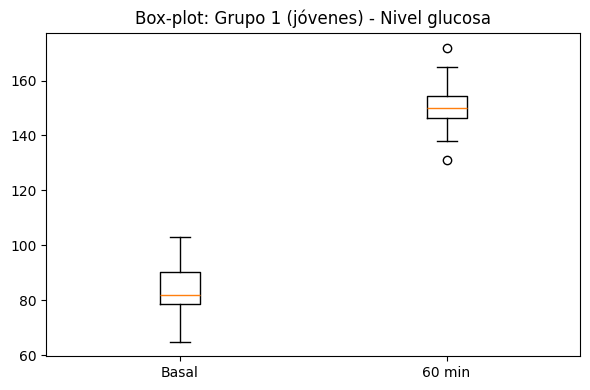

In [56]:
# Boxplot conjunto
fig, ax = plt.subplots(figsize=(6,4))
ax.boxplot([g1[col_basal].dropna(), g1[col_60].dropna()], tick_labels=['Basal','60 min'])
ax.set_title('Box-plot: Grupo 1 (jóvenes) - Nivel glucosa')
plt.tight_layout()
plt.show()

**Cuartiles y outliers (grupo 1 — jóvenes)**

- Los cuartiles imprimidos arriba indican Q1 (25%), Q2 (mediana, 50%) y Q3 (75%) para cada variable.
- Un valor fuera del rango [Q1 - 1.5·IQR, Q3 + 1.5·IQR] se considera atípico según la regla del boxplot.
- El box-plot generado muestra visualmente la mediana, los cuartiles y cualquier valor atípico detectado.

In [57]:
# Pruebas de normalidad para 'Nivel glucosa 60 min' en ambos grupos
import scipy.stats as ss
col_group = 'Grupo de control'
col_60 = 'Nivel glucosa 60 min'
alpha = 0.05
for g in sorted(df[col_group].unique()):
    series = df.loc[df[col_group] == g, col_60].dropna()
    n = len(series)
    print(f'--- Grupo {g} (n={n}) ---')
    # Shapiro-Wilk
    try:
        s_stat, s_p = ss.shapiro(series)
        print(f'Shapiro-Wilk: stat={s_stat:.4f}, p={s_p:.4f} ->', 'Normal' if s_p>alpha else 'No normal')
    except Exception as e:
        print('Shapiro-Wilk: error', e)
    # D'Agostino K^2
    try:
        k_stat, k_p = ss.normaltest(series)
        print(f"D'Agostino K^2: stat={k_stat:.4f}, p={k_p:.4f} ->", 'Normal' if k_p>alpha else 'No normal')
    except Exception as e:
        print("D'Agostino: error", e)

    try:
        ad = ss.anderson(series, dist='norm', method='interpolate')
    except TypeError:
        ad = ss.anderson(series, dist='norm')
    
    pval = ad.pvalue
    print(f'Anderson-Darling: stat={ad.statistic:.4f}, p={pval:.4f} ->', 'Normal' if pval>alpha else 'No normal')
    
    print()

--- Grupo 1 (n=35) ---
Shapiro-Wilk: stat=0.9626, p=0.2734 -> Normal
D'Agostino K^2: stat=3.6141, p=0.1641 -> Normal
Anderson-Darling: stat=0.6437, p=0.0887 -> Normal

--- Grupo 2 (n=30) ---
Shapiro-Wilk: stat=0.9776, p=0.7592 -> Normal
D'Agostino K^2: stat=0.5379, p=0.7642 -> Normal
Anderson-Darling: stat=0.2678, p=0.1500 -> Normal



**Interpretación (nivel de significación α = 0.05)**

- Se muestran los resultados de Shapiro-Wilk, D'Agostino (K^2) y Anderson-Darling para `Nivel glucosa 60 min` en cada grupo de control.
- Regla: si el p-valor < 0.05 (Shapiro o D'Agostino) rechazamos normalidad. En Anderson-Darling comparamos la estadística con el valor crítico al 5%.
- Interpreta los resultados numéricos:
  - Ambos grupos pueden considerarse aproximadamente normales (α=0.05), por lo que el uso de pruebas paramétricas (p. ej. t-test para medias) es razonable.

# Ejercicio 3

## A.

In [58]:
# Cálculo de IC y contraste para el nivel medio en jóvenes (Grupo 1)
col_group = 'Grupo de control'
col_basal = 'Nivel glucosa basal'
g1 = df.loc[df[col_group] == 1, col_basal].dropna()

n = len(g1)
mean = g1.mean()
s = g1.std(ddof=1)
se = s / (n**0.5)

# IC 95%
t95 = ss.t.ppf(1-0.025, df=n-1)
margin95 = t95 * se
ci95 = (mean - margin95, mean + margin95)

# IC 99%
t99 = ss.t.ppf(1-0.005, df=n-1)
margin99 = t99 * se
ci99 = (mean - margin99, mean + margin99)

# Contraste H0: mu = 88 (bilateral)
mu0 = 88
t_stat = (mean - mu0) / se
pval = 2 * (1 - ss.t.cdf(abs(t_stat), df=n-1))

print('Grupo 1 (jóvenes) — n =', n)
print(f'Media muestral = {mean:.4f}, s = {s:.4f}, SE = {se:.4f}')
print(f'IC 95% para la media: [{ci95[0]:.4f}, {ci95[1]:.4f}]')
print(f'IC 99% para la media: [{ci99[0]:.4f}, {ci99[1]:.4f}]')
print('\nContraste H0: mu = 88 (bilateral)')
print(f't = {t_stat:.4f}, p-value = {pval:.4f}')
print('Decisión (α=0.05):', 'Rechazar H0' if pval < 0.05 else 'No rechazar H0')

Grupo 1 (jóvenes) — n = 35
Media muestral = 84.6857, s = 8.8443, SE = 1.4950
IC 95% para la media: [81.6476, 87.7238]
IC 99% para la media: [80.6069, 88.7646]

Contraste H0: mu = 88 (bilateral)
t = -2.2170, p-value = 0.0334
Decisión (α=0.05): Rechazar H0


Dado p = 0.0334 < 0.05 y 88 no pertenece al IC al 95% (88 > 87.7238), no se puede admitir que la media poblacional sea 88 al nivel de significación 5% (rechazamos H0).

## B.

In [59]:
# IC 95% para la diferencia de medias (adultos - jóvenes) usando Welch
col_group = 'Grupo de control'
col_basal = 'Nivel glucosa basal'

g1 = df.loc[df[col_group]==1, col_basal].dropna()
g2 = df.loc[df[col_group]==2, col_basal].dropna()

n1 = len(g1); n2 = len(g2)
mean1 = g1.mean(); mean2 = g2.mean()
s1 = g1.std(ddof=1); s2 = g2.std(ddof=1)

diff = mean2 - mean1  # adultos - jóvenes
se = (s1**2/n1 + s2**2/n2)**0.5
# Welch df
df_w = (s1**2/n1 + s2**2/n2)**2 / ((s1**4)/((n1**2)*(n1-1)) + (s2**4)/((n2**2)*(n2-1)))

alpha = 0.05
tcrit = ss.t.ppf(1-alpha/2, df=df_w)
margin = tcrit * se
ci_low = diff - margin
ci_high = diff + margin

# t-stat and p-value
t_stat = diff / se
pval = 2 * (1 - ss.t.cdf(abs(t_stat), df=df_w))

print('n1 (jovenes) =', n1)
print('mean1 (jovenes) =', round(mean1,4), 's1 =', round(s1,4))
print('n2 (adultos) =', n2)
print('mean2 (adultos) =', round(mean2,4), 's2 =', round(s2,4))
print('\nDiferencia (adultos - jovenes) =', round(diff,4))
print('IC 95% (Welch) = [', round(ci_low,4), ',', round(ci_high,4), ']')
print('t (Welch) =', round(t_stat,4), ', df =', round(df_w,2), ', p =', round(pval,4))

if pval < 0.05:
    print('\nConclusion (alpha=0.05): Rechazar H0. Las medias son significativamente diferentes (adultos > jovenes).')
else:
    print('\nConclusion (alpha=0.05): No se rechaza H0. No hay evidencia de diferencia significativa en las medias.')

n1 (jovenes) = 35
mean1 (jovenes) = 84.6857 s1 = 8.8443
n2 (adultos) = 30
mean2 (adultos) = 89.4 s2 = 7.3466

Diferencia (adultos - jovenes) = 4.7143
IC 95% (Welch) = [ 0.7006 , 8.728 ]
t (Welch) = 2.3472 , df = 62.95 , p = 0.0221

Conclusion (alpha=0.05): Rechazar H0. Las medias son significativamente diferentes (adultos > jovenes).


**Interpretación (diferencia de medias — nivel basal)**

- IC 95% para (adultos - jóvenes): si el intervalo no contiene 0, hay evidencia de diferencia significativa a α=0.05.
- Resultado: el intervalo impreso por la celda anterior muestra la diferencia estimada y su IC 95%; <br>si el intervalo no incluye 0, concluimos que los niveles basales difieren entre adultos y jóvenes.
- En caso contrario, no habría evidencia para afirmar diferencia.

(La celda anterior usa el procedimiento de Welch, que no asume varianzas iguales.)

## C.

In [60]:
# Proporción con nivel basal > 95 mg/dL: IC 98% (Wilson) y contraste H0: p = 0.15
import scipy.stats as ss
col_basal = 'Nivel glucosa basal'
N = len(df)
count = (df[col_basal] > 95).sum()
phat = count / N

# Wilson score interval (98%)
z = ss.norm.ppf(1-0.01)
center = (phat + z**2/(2*N)) / (1 + z**2/N)
half = z * ( (phat*(1-phat)/N + z**2/(4*N**2))**0.5 ) / (1 + z**2/N)
ci_low = center - half
ci_high = center + half

# Test H0: p0 = 0.15 (two-sided)
p0 = 0.15
se0 = (p0*(1-p0)/N)**0.5
z_stat = (phat - p0) / se0
pval = 2 * (1 - ss.norm.cdf(abs(z_stat)))

print('N =', N)
print('count >95 =', int(count))
print(f'p̂ = {phat:.4f}')
print(f'IC 98% (Wilson): [{ci_low:.4f}, {ci_high:.4f}]')
print('\nContraste H0: p = 0.15 (bilateral)')
print(f'z = {z_stat:.4f}, p-value = {pval:.4f}')
print('Decisión (α=0.05):', 'Rechazar H0' if pval < 0.05 else 'No rechazar H0')

N = 65
count >95 = 11
p̂ = 0.1692
IC 98% (Wilson): [0.0876, 0.3017]

Contraste H0: p = 0.15 (bilateral)
z = 0.4342, p-value = 0.6641
Decisión (α=0.05): No rechazar H0


La proporción muestral con nivel basal >95 es ~16.9%.\
El intervalo 98% contiene 0.15, y el contraste no rechaza H0, por lo que no hay evidencia suficiente (α=0.05) para afirmar que la proporción poblacional difiera de 0.15.

# Ejercicio 2

## A.

In [61]:
# Relación lineal entre nivel basal y nivel a 60 min (Grupo 1)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress

col_group = 'Grupo de control'
col_basal = 'Nivel glucosa basal'
col_60 = 'Nivel glucosa 60 min'

g1 = df.loc[df[col_group]==1, [col_basal, col_60]].dropna()
x = g1[col_basal].values
y = g1[col_60].values

# Estadísticos
r, p_r = pearsonr(x, y)
lr = linregress(x, y)
r2 = lr.rvalue**2

print('n =', len(x))
print(f'Pearson r = {r:.4f}, p = {p_r:.4f}')
print(f'Regression slope = {lr.slope:.4f}, intercept = {lr.intercept:.4f}, R^2 = {r2:.4f}')


n = 35
Pearson r = 0.7964, p = 0.0000
Regression slope = 0.6969, intercept = 91.3837, R^2 = 0.6343


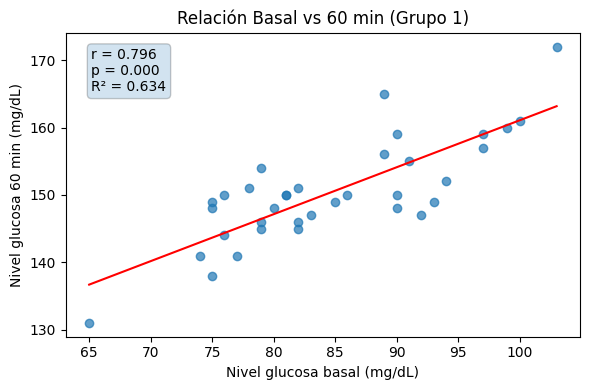

In [62]:
# Gráfico
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x, y, alpha=0.7)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, lr.intercept + lr.slope*xs, color='red')
ax.set_xlabel('Nivel glucosa basal (mg/dL)')
ax.set_ylabel('Nivel glucosa 60 min (mg/dL)')
ax.set_title('Relación Basal vs 60 min (Grupo 1)')
ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p_r:.3f}\nR² = {r2:.3f}', transform=ax.transAxes,
        fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.2))
plt.tight_layout()
plt.show()

existe una relación lineal positiva fuerte entre nivel basal y nivel a 60 min en los jóvenes; el nivel basal explica ~63% de la variación del nivel a 60 min, por lo que la regresión lineal es razonable como modelo simple.

* B.

In [63]:
# Modelo lineal y estimación para un paciente con nivel basal = 83 mg/dL (Grupo 1)
import numpy as np
from scipy.stats import linregress, t

col_group = 'Grupo de control'
col_basal = 'Nivel glucosa basal'
col_60 = 'Nivel glucosa 60 min'

g1 = df.loc[df[col_group]==1, [col_basal, col_60]].dropna()
x = g1[col_basal].values
y = g1[col_60].values
n = len(x)

lr = linregress(x, y)
slope = lr.slope
intercept = lr.intercept

y_hat = intercept + slope * 83
# errores y SSE
resid = y - (intercept + slope * x)
SSE = np.sum(resid**2)
se_reg = np.sqrt(SSE / (n - 2))

x_mean = x.mean()
Sxx = np.sum((x - x_mean)**2)

# IC para la media en x0=83
x0 = 83
se_mean = se_reg * np.sqrt(1/n + (x0 - x_mean)**2 / Sxx)
# Intervalo de predicción (individuo)
se_pred = se_reg * np.sqrt(1 + 1/n + (x0 - x_mean)**2 / Sxx)

tcrit = t.ppf(0.975, df=n-2)
ci_mean_low = y_hat - tcrit * se_mean
ci_mean_high = y_hat + tcrit * se_mean
pi_low = y_hat - tcrit * se_pred
pi_high = y_hat + tcrit * se_pred

print('Ecuación del modelo: Nivel60 = {:.4f} + {:.4f} * NivelBasal'.format(intercept, slope))
print('R^2 (aprox): {:.4f}'.format(lr.rvalue**2))
print('\nEstimación puntual para basal = 83 mg/dL:')
print('Predicción (media esperada) = {:.3f} mg/dL'.format(y_hat))
print('IC 95% para la media en x=83: [{:.3f}, {:.3f}]'.format(ci_mean_low, ci_mean_high))
print('Intervalo de predicción 95% (individuo): [{:.3f}, {:.3f}]'.format(pi_low, pi_high))

Ecuación del modelo: Nivel60 = 91.3837 + 0.6969 * NivelBasal
R^2 (aprox): 0.6343

Estimación puntual para basal = 83 mg/dL:
Predicción (media esperada) = 149.225 mg/dL
IC 95% para la media en x=83: [147.561, 150.889]
Intervalo de predicción 95% (individuo): [139.418, 159.033]


- Obtener un modelo lineal que explica el nivel de glucosa en sangre a los 60 minutos en función del nivel basal del paciente <br>
y realizar la estimación para un paciente cuyo nivel basal es 83 mg/Dl.

## C.

* El R² del modelo es ≈ 0.6343, por tanto la parte no explicada es (1 − R²)·100% ≈ 36.57% (≈ 36.6%).<br>Eso significa que, del total de la variación observada en Nivel(60 min), el 63.4% se explica por el nivel basal y el 36.6% restante viene de ruido, errores de medida o factores que no hemos incluido en el modelo.
* Qué NO significa: no es “el porcentaje de predicciones erradas” ni prueba causalidad; es solo una medida de qué parte de la varianza queda sin explicar.
* Implicación que con ~36.6% sin explicar conviene considerar más variables, interacciones o modelos no lineales y revisar los residuos para mejorar el ajuste.

## D.

In [64]:
# Cambio esperado en Nivel(60 min) por un aumento de 5 mg/dL en basal
col_group = 'Grupo de control'
col_basal = 'Nivel glucosa basal'
col_60 = 'Nivel glucosa 60 min'

g1 = df.loc[df[col_group]==1, [col_basal, col_60]].dropna()
lr = linregress(g1[col_basal].values, g1[col_60].values)

delta_basal = 5
delta_y = lr.slope * delta_basal

print(delta_y)

3.4844334149800176


Usando la pendiente del modelo (≈0.6969), un aumento de 5 mg/dL en el basal implica una subida esperada en la media de Nivel(60 min) de 0.6969×5 ≈ 3.48 mg/dL.
(Esto es el cambio esperado en la media; la respuesta individual puede variar alrededor de este valor.)